In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Google Drive가 성공적으로 마운트되면, `/content/drive/MyDrive/` 경로를 통해 Drive의 파일에 접근할 수 있습니다. 예를 들어, `My Drive` 폴더 안에 `my_data.csv` 파일이 있다면 다음과 같이 읽을 수 있습니다:

In [13]:
import pandas as pd

# Google Drive 내 파일 경로를 지정하여 데이터 불러오기
# '/content/drive/MyDrive/'는 Google Drive의 루트 경로입니다.
base_path = '/content/drive/MyDrive/2주차 4차시 실습 코드 및 데이터-20260828/'

# train.csv 파일 불러오기
train_file_path = base_path + 'train.csv'
train_data = pd.read_csv(train_file_path)

# test.csv 파일 불러오기
test_file_path = base_path + 'test.csv'
test_data = pd.read_csv(test_file_path)

print('Train Data Head:')
display(train_data.head())

print('\nTest Data Head:')
display(test_data.head())

Train Data Head:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Test Data Head:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


## `train_data` 컬럼 정보 및 결측치 확인

In [18]:
print('--- train_data info ---')
train_data.info()

print('\n--- train_data missing values ---')
display(train_data.isnull().sum())

--- train_data info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

--- train_data missing values ---


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


## `test_data` 컬럼 정보 및 결측치 확인

In [19]:
print('--- test_data info ---')
test_data.info()

print('\n--- test_data missing values ---')
display(test_data.isnull().sum())

--- test_data info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB

--- test_data missing values ---


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1


## (1) 형태와 통계값 탐색: 데이터의 분포 및 값 확인

### 데이터 셋의 형태 (총 행/칼럼 개수)

In [20]:
print(f"train_data의 행과 열: {train_data.shape}")
print(f"test_data의 행과 열: {test_data.shape}")

train_data의 행과 열: (891, 12)
test_data의 행과 열: (418, 12)


#### 해석:
*   `train_data`는 891개의 행(승객)과 12개의 열(특성)으로 구성되어 있습니다.
*   `test_data`는 418개의 행(승객)과 11개의 열(특성)으로 구성되어 있습니다. `Survived` 컬럼이 없는 것이 특징입니다.

### 통계값 (변수별 평균값, 중앙값, 사분위수, 최소·최대값 등)

In [21]:
print('--- train_data 통계값 ---')
display(train_data.describe())

print('\n--- test_data 통계값 ---')
display(test_data.describe())

--- train_data 통계값 ---


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200



--- test_data 통계값 ---


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,418.000000,418.000000,418.000000,332.000000,418.000000,418.000000,417.000000
mean,1100.500000,0.363636,2.265550,30.272590,0.447368,0.392344,35.627188
std,120.810458,0.481622,0.841838,14.181209,0.896760,0.981429,55.907576
min,892.000000,0.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,996.250000,0.000000,1.000000,21.000000,0.000000,0.000000,7.895800
50%,1100.500000,0.000000,3.000000,27.000000,0.000000,0.000000,14.454200
75%,1204.750000,1.000000,3.000000,39.000000,1.000000,0.000000,31.500000
max,1309.000000,1.000000,3.000000,76.000000,8.000000,9.000000,512.329200


#### 해석:
*   **Survived**: `train_data`에서만 존재하는 생존 여부(타겟 변수)입니다. 평균이 약 0.38로, 약 38%의 승객이 생존했음을 알 수 있습니다.
*   **Pclass**: 승객 등급으로, 1, 2, 3등석이 있습니다. 대부분 3등석(최빈값) 승객이 많습니다.
*   **Age**: `train_data`와 `test_data` 모두 `count`가 `shape`의 행 개수보다 적습니다. 이는 결측치가 존재함을 의미하며, 이전에 `isnull().sum()`으로 확인했던 내용과 일치합니다. 평균 연령은 약 29~30세입니다.
*   **Fare**: 요금은 최소 0에서 최대 512까지 분포하며, 편차가 큽니다. `test_data`에서 `Fare`의 최소값이 0인 것을 확인할 수 있는데, 이는 무료 승선자가 있을 수 있음을 시사합니다.
*   **SibSp (형제/배우자 수)** 및 **Parch (부모/자녀 수)**: 대부분의 승객은 동반 가족이 없거나 적습니다 (최대 8명, 6명).
*   **PassengerId**: 고유 식별자로, 분석에 직접적으로 사용되는 수치는 아닙니다.

## (2) 변수 혹은 변수 간의 관계 및 특성에 대한 탐색 (시각화)

/tmp/ipykernel_607/648129241.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Survived', data=train_data, palette='viridis')


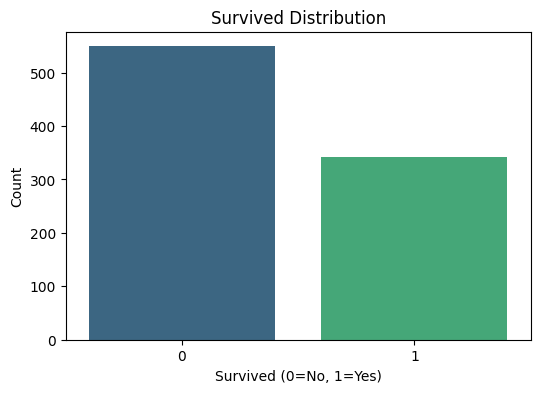

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 4))
sns.countplot(x='Survived', data=train_data, palette='viridis')
plt.title('Survived Distribution')
plt.xlabel('Survived (0=No, 1=Yes)')
plt.ylabel('Count')
plt.show()

#### 해석:
*   생존(1)한 승객보다 사망(0)한 승객의 수가 더 많습니다. 이는 생존 예측 모델을 만들 때 클래스 불균형을 고려해야 할 수도 있음을 시사합니다.

/tmp/ipykernel_607/3281203322.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Pclass', data=train_data, palette='coolwarm')
/tmp/ipykernel_607/3281203322.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Pclass', data=test_data, palette='coolwarm')


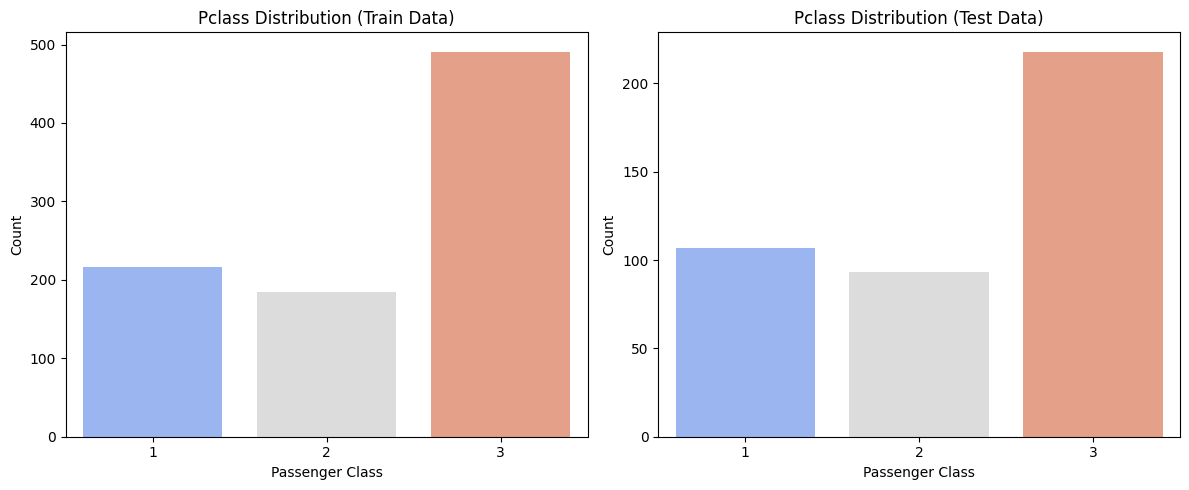

In [23]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.countplot(x='Pclass', data=train_data, palette='coolwarm')
plt.title('Pclass Distribution (Train Data)')
plt.xlabel('Passenger Class')
plt.ylabel('Count')

plt.subplot(1, 2, 2)
sns.countplot(x='Pclass', data=test_data, palette='coolwarm')
plt.title('Pclass Distribution (Test Data)')
plt.xlabel('Passenger Class')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

### 'SibSp' (형제/배우자 수)와 'Survived' 관계 시각화

/tmp/ipykernel_607/2914252550.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='SibSp', y='Survived', data=train_data, palette='plasma')


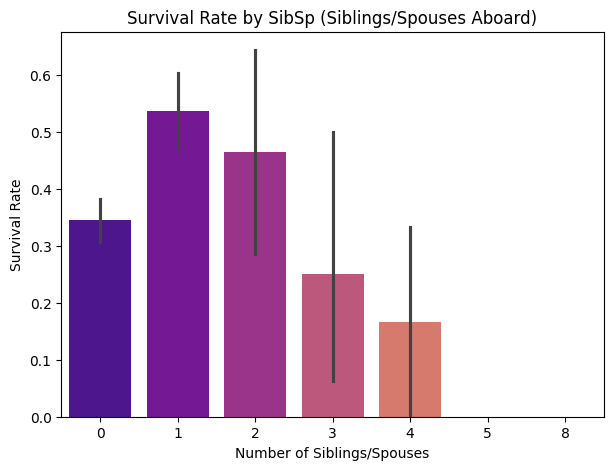

In [28]:
plt.figure(figsize=(7, 5))
sns.barplot(x='SibSp', y='Survived', data=train_data, palette='plasma')
plt.title('Survival Rate by SibSp (Siblings/Spouses Aboard)')
plt.xlabel('Number of Siblings/Spouses')
plt.ylabel('Survival Rate')
plt.show()

#### 해석:
*   형제/배우자가 없는(0명) 승객의 생존율이 가장 낮고, 1~2명의 형제/배우자와 함께 탑승한 경우 생존율이 다소 높아지는 경향을 보입니다. 하지만 그 이상 (3명 이상)의 형제/배우자가 있는 경우 생존율이 급격히 낮아집니다. 이는 적절한 규모의 가족과 함께하는 것이 생존에 유리할 수 있음을 시사합니다.

### 'Parch' (부모/자녀 수)와 'Survived' 관계 시각화

/tmp/ipykernel_607/4054440639.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Parch', y='Survived', data=train_data, palette='magma')


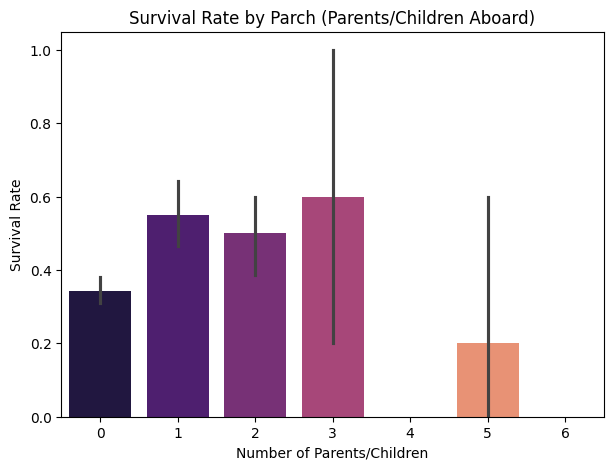

In [29]:
plt.figure(figsize=(7, 5))
sns.barplot(x='Parch', y='Survived', data=train_data, palette='magma')
plt.title('Survival Rate by Parch (Parents/Children Aboard)')
plt.xlabel('Number of Parents/Children')
plt.ylabel('Survival Rate')
plt.show()

#### 해석:
*   부모/자녀가 없는(0명) 승객의 생존율이 낮은 편이며, 1~3명의 부모/자녀와 함께 탑승한 경우 생존율이 높아집니다. 4명 이상의 부모/자녀가 있는 경우 다시 생존율이 낮아지는 경향을 보입니다. `SibSp`와 비슷한 패턴입니다.

### 'FamilySize' (가족 규모) 파생 변수 생성 및 'Survived' 관계 시각화

/tmp/ipykernel_607/1358415873.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='FamilySize', y='Survived', data=train_data, palette='viridis')


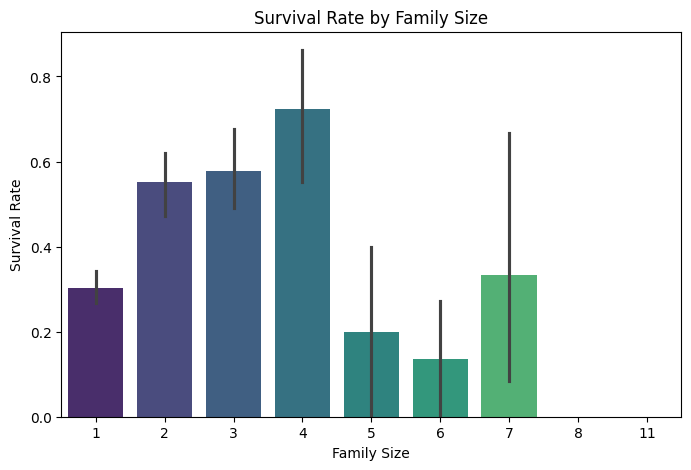

In [30]:
# FamilySize (본인 포함 가족 수) 파생 변수 생성
train_data['FamilySize'] = train_data['SibSp'] + train_data['Parch'] + 1

plt.figure(figsize=(8, 5))
sns.barplot(x='FamilySize', y='Survived', data=train_data, palette='viridis')
plt.title('Survival Rate by Family Size')
plt.xlabel('Family Size')
plt.ylabel('Survival Rate')
plt.show()

#### 해석:
*   혼자 탑승한 승객(`FamilySize`=1)은 생존율이 가장 낮습니다.
*   2~4명 정도의 가족 규모를 가진 승객들이 가장 높은 생존율을 보입니다.
*   가족 규모가 5명 이상인 경우 생존율이 다시 급격히 낮아집니다. 이는 대가족의 경우 탈출이 더 어려웠을 수 있음을 나타냅니다.

## 탐색적 데이터 분석 (EDA) 요약 및 다음 단계 제안

지금까지 Titanic 데이터셋에 대한 탐색적 데이터 분석을 수행했습니다.

### 주요 발견 사항:
*   **결측치**: `Age`, `Cabin`, `Embarked` (train_data), `Age`, `Fare`, `Cabin` (test_data)에 결측치가 존재합니다. 이들은 모델 학습 전에 적절히 처리되어야 합니다.
*   **데이터 형태**: `train_data`는 891개의 샘플과 12개의 특성(`Survived` 포함)을, `test_data`는 418개의 샘플과 11개의 특성을 가지고 있습니다.
*   **성별(`Sex`)**: 여성이 남성보다 생존율이 훨씬 높습니다. 이는 매우 중요한 예측 요인입니다.
*   **승객 등급(`Pclass`)**: 1등석 승객의 생존율이 가장 높았으며, 3등석 승객의 생존율이 가장 낮았습니다.
*   **탑승 항구(`Embarked`)**: C (Cherbourg) 항구에서 탑승한 승객의 생존율이 가장 높게 나타났습니다.
*   **나이(`Age`)**: 어린아이들의 생존율이 높았고, 나이가 많아질수록 생존율이 감소하는 경향을 보였습니다.
*   **요금(`Fare`)**: 높은 요금을 지불한 승객들이 더 높은 생존율을 보였습니다.
*   **가족 규모(`FamilySize`)**: 2~4명 규모의 가족이 가장 높은 생존율을 보였고, 혼자이거나 대가족인 경우 생존율이 낮았습니다.

### 다음 단계 제안:
이러한 분석을 바탕으로, 다음 단계에서는 결측치 처리, 범주형 변수 인코딩, 새로운 특성 생성(예: `FamilySize`의 범주화), 그리고 모델 학습을 위한 데이터 전처리 과정을 진행할 수 있습니다. 어떤 부분부터 시작하시겠습니까?

#### 해석:
*   `train_data`와 `test_data` 모두 3등석 승객의 수가 가장 많고, 다음으로 1등석, 2등석 순입니다.
*   이는 Pclass가 생존에 중요한 영향을 미칠 수 있음을 예상하게 합니다. 일반적으로 낮은 등급의 승객일수록 생존율이 낮을 수 있습니다.

### 'Sex'와 'Survived' 관계 시각화

/tmp/ipykernel_607/1833670109.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=train_data, palette='coolwarm')


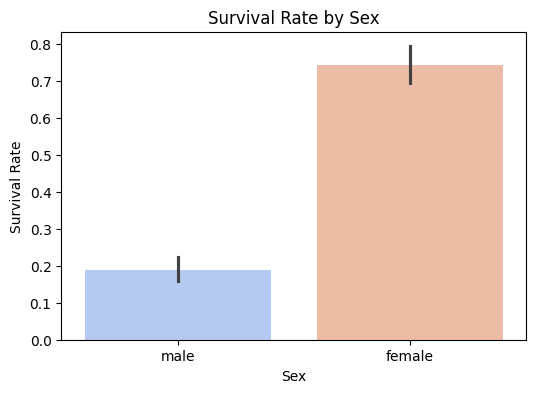

In [24]:
plt.figure(figsize=(6, 4))
sns.barplot(x='Sex', y='Survived', data=train_data, palette='coolwarm')
plt.title('Survival Rate by Sex')
plt.xlabel('Sex')
plt.ylabel('Survival Rate')
plt.show()

#### 해석:
*   여성(`female`)이 남성(`male`)보다 생존율이 훨씬 높은 것을 명확하게 확인할 수 있습니다. 이는 성별이 생존에 매우 중요한 요인임을 시사합니다.

### 'Embarked'와 'Survived' 관계 시각화

/tmp/ipykernel_607/1379454567.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Embarked', y='Survived', data=train_data, palette='viridis')


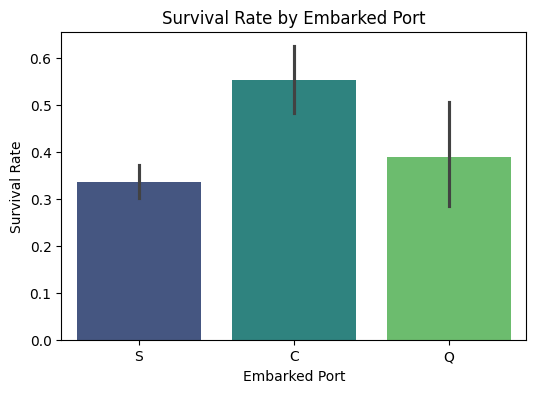

In [25]:
plt.figure(figsize=(6, 4))
sns.barplot(x='Embarked', y='Survived', data=train_data, palette='viridis')
plt.title('Survival Rate by Embarked Port')
plt.xlabel('Embarked Port')
plt.ylabel('Survival Rate')
plt.show()

#### 해석:
*   C (Cherbourg) 항구에서 탑승한 승객의 생존율이 가장 높고, Q (Queenstown), S (Southampton) 순으로 나타납니다. 탑승 항구 또한 생존에 영향을 미 미쳤을 수 있습니다.

### 'Age' 분포 시각화 및 'Survived' 관계 확인

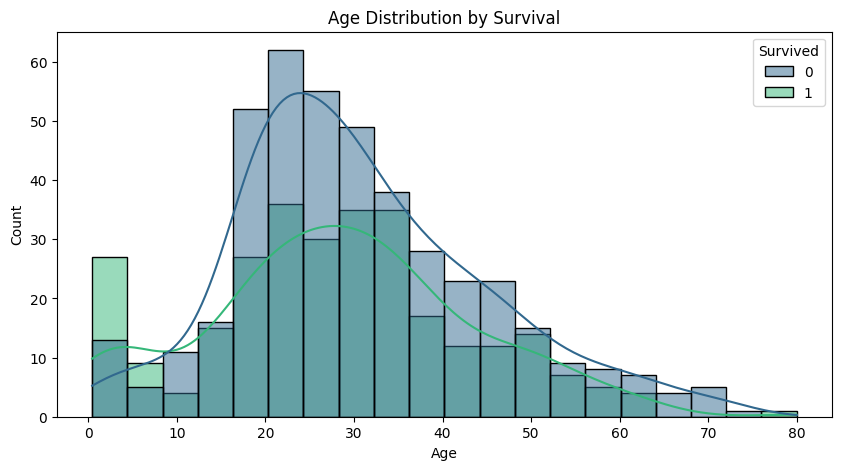

In [26]:
plt.figure(figsize=(10, 5))
sns.histplot(data=train_data, x='Age', hue='Survived', kde=True, palette='viridis')
plt.title('Age Distribution by Survival')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

#### 해석:
*   어린 아이들(0~10세)의 생존율이 비교적 높아 보입니다.
*   20대 후반에서 30대 초반의 사망자 수가 가장 많습니다.
*   나이가 많아질수록 생존자 수가 감소하는 경향을 보입니다.
*   `Age`에 결측치가 있었으므로, 이 부분을 어떻게 처리할지에 대한 고려가 필요합니다.

### 'Fare' 분포 시각화 및 'Survived' 관계 확인

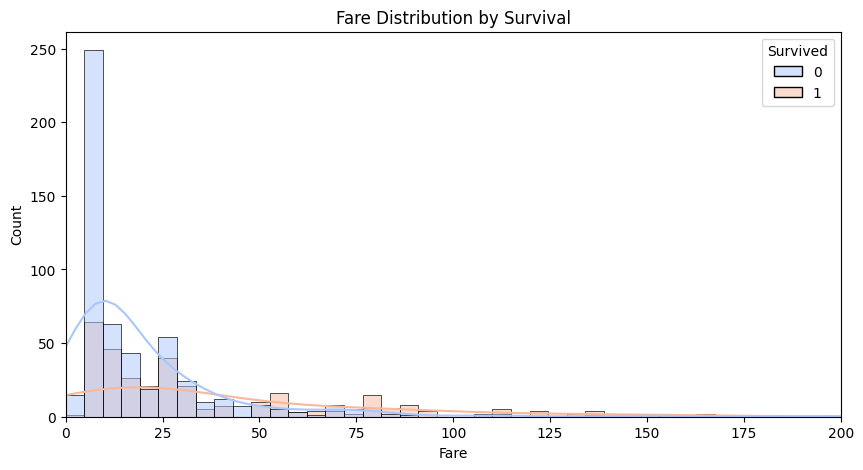

In [27]:
plt.figure(figsize=(10, 5))
sns.histplot(data=train_data, x='Fare', hue='Survived', kde=True, palette='coolwarm')
plt.title('Fare Distribution by Survival')
plt.xlabel('Fare')
plt.ylabel('Count')
plt.xlim(0, 200) # 이상치로 인해 분포가 잘 보이지 않을 수 있어 x축 범위 제한
plt.show()

#### 해석:
*   낮은 요금을 지불한 승객(특히 0-25 범위)의 사망자 수가 생존자 수보다 훨씬 많습니다.
*   상대적으로 높은 요금을 지불한 승객은 생존율이 더 높은 경향을 보입니다. 이는 Pclass와의 연관성 때문일 수 있습니다 (높은 Pclass일수록 요금이 비싸고 생존율이 높았음).

Google Drive 내에서 파일의 정확한 경로를 찾으려면 다음 코드를 사용하여 `/content/drive/MyDrive/` 경로 아래의 내용을 나열할 수 있습니다. `train.csv` 파일이 어느 폴더에 있는지 확인하고, 그 경로를 위 코드에 맞게 수정해주세요.